# **Classification**

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OrdinalEncoder,
    KBinsDiscretizer,
    FunctionTransformer,
    label_binarize
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [60]:
df_train = pd.read_csv('../data/cleaned_train.csv')
df_test = pd.read_csv('../data/cleaned_test.csv')

### **Distribution of multiclass target variable**

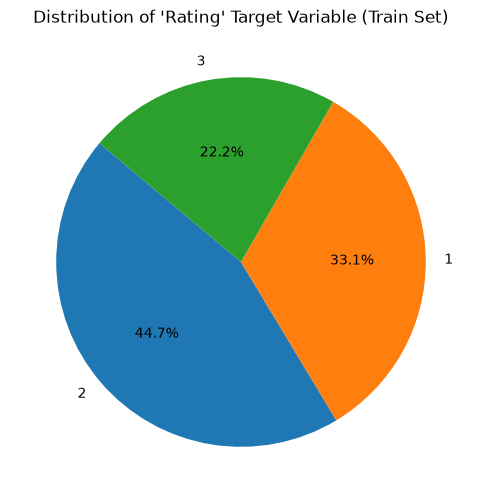

In [61]:
# Pie chart of the distribution of the 'Rating' target variable
rating_counts = df_train['Rating'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of 'Rating' Target Variable (Train Set)")
plt.show()

### **Creation and distribution visualization of binary target variable**

In [62]:
# Descriptive statistics of ComMaxPlaytime, used to decide the threshold for the binary target
print(df_train['ComMaxPlaytime'].describe())

# Percentiles help us understand the distribution shape and where most games fall
percentiles = [25, 50, 75, 90]
percentile_values = np.percentile(df_train['ComMaxPlaytime'].dropna(), percentiles)

print(f"\n25% of the games last less than: {percentile_values[0]} min")
print(f"50% of the games (Median) last less than: {percentile_values[1]} min")
print(f"75% of the games last less than: {percentile_values[2]} min")
print(f"90% of the games last less than: {percentile_values[3]} min")

count    15779.000000
mean        63.696907
std         56.052764
min          1.000000
25%         30.000000
50%         45.000000
75%         90.000000
max        360.000000
Name: ComMaxPlaytime, dtype: float64

25% of the games last less than: 30.0 min
50% of the games (Median) last less than: 45.0 min
75% of the games last less than: 90.0 min
90% of the games last less than: 120.0 min


#### **Threshold Selection for Binary Target (`is_long_game`)**

Based on the descriptive statistics of the `ComMaxPlaytime` variable, we established a threshold of **60 minutes** to classify the games. This choice is driven by two main factors:

* **Statistical Balance:** A 60-minute threshold sits perfectly between the median (45 min) and the 75th percentile (90 min), splitting the dataset into well-proportioned classes (approximately 57% "Fast" and 43% "Long" games). This prevents class imbalance issues during model training, allowing our classifiers to learn effectively without requiring synthetic resampling techniques.
* **Domain Interpretability:** From a board gamer's perspective, the 1-hour mark is a natural and intuitive psychological boundary. It effectively separates quick or medium-weight filler games from those requiring a more significant time commitment.

--- Class Distribution with threshold 60 min (Train Set) ---
Class 0 (Fast < 60m):  56.63%
Class 1 (Long >=60m):  43.37%

[OK] Class balance is suitable for training.


/tmp/ipykernel_16702/3612199220.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_long_game', data=df_train, palette='coolwarm')


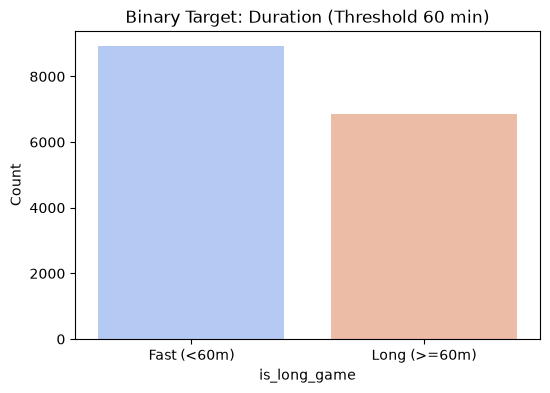

In [63]:
THRESHOLD_MINUTES = 60

# Apply to both sets
df_train['is_long_game'] = (df_train['ComMaxPlaytime'] >= THRESHOLD_MINUTES).astype(int)
df_test['is_long_game'] = (df_test['ComMaxPlaytime'] >= THRESHOLD_MINUTES).astype(int)

# Percentage distribution of the two classes (on the train set)
counts = df_train['is_long_game'].value_counts(normalize=True) * 100
print(f"--- Class Distribution with threshold {THRESHOLD_MINUTES} min (Train Set) ---")
print(f"Class 0 (Fast < {THRESHOLD_MINUTES}m):  {counts[0]:.2f}%")
print(f"Class 1 (Long >={THRESHOLD_MINUTES}m):  {counts[1]:.2f}%")

if counts[1] < 30:
    print("\n[!] WARNING: The 'Long' class is underrepresented. Consider lowering the threshold to the median (45 min).")
else:
    print("\n[OK] Class balance is suitable for training.")

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='is_long_game', data=df_train, palette='coolwarm')
plt.title(f'Binary Target: Duration (Threshold {THRESHOLD_MINUTES} min)')
plt.xticks([0, 1], [f'Fast (<{THRESHOLD_MINUTES}m)', f'Long (>={THRESHOLD_MINUTES}m)'])
plt.ylabel('Count')
plt.show()

### **Feature and Target Selection**

In [64]:
# Extract X and y for the training set
X_train = df_train.drop(columns=['Rating', 'is_long_game'])
y_train = df_train[['Rating', 'is_long_game']]

# Extract X and y for the test set
X_test = df_test.drop(columns=['Rating', 'is_long_game'])
y_test = df_test[['Rating', 'is_long_game']]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (15779, 24)
X_test shape: (3950, 24)


### **Helper functions**

In [ ]:
CONFUSION_CMAP = "Blues"


def tune_and_evaluate(estimator, param_grid, X_train, y_train, X_test, y_test, scoring, cv=5, label=""):
    """
    Run GridSearchCV on `estimator` using `cv`-fold cross-validation, then evaluate
    the best model on the held-out test set.

    Returns
    -------
    best_estimator : the fitted estimator with the best cross-validated score
    y_pred : predictions of `best_estimator` on X_test
    """
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
    )

    print(f"Starting hyperparameter tuning{f' - {label}' if label else ''}...")
    grid_search.fit(X_train, y_train)

    print("\nBEST CONFIGURATION FOUND:")
    print("-------------------------------")
    print(f"Best params: {grid_search.best_params_}")
    print(f"Best cross-validation {scoring} score: {grid_search.best_score_:.2%}")

    best_estimator = grid_search.best_estimator_
    y_pred = best_estimator.predict(X_test)

    print("\nFinal results on the test set:")
    print(classification_report(y_test, y_pred))

    return best_estimator, y_pred


def plot_confusion(y_true, y_pred, title, display_labels=None, cmap=CONFUSION_CMAP):
    """Plot a confusion matrix with a consistent style across the notebook."""
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, cmap=cmap, display_labels=display_labels
    )
    plt.title(title)
    plt.grid(False)
    plt.show()


def print_feature_importance(features, importances):
    """Print feature importances sorted from most to least predictive."""
    ranked = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)
    print("Feature importance")
    for col, imp in ranked:
        print(f"{col}: {imp:.4f}")


def plot_binary_roc(model, X_test, y_test, title):
    """Plot the ROC curve of a binary classifier."""
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


def plot_multiclass_roc(model, X_test, y_test, classes, title):
    """Plot the one-vs-rest ROC curve for each class of a multiclass classifier."""
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(8, 6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Class {cls} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

### **KNN Classifier - Multiclass classification**

#### Selecting features

In [66]:
features_knn_multi = [
    'Avg_popularity_log',
    'YearPublished',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'NumWeightVotes_log',
    'ComMinPlaytime',
]

X_train_knn_multi = X_train[features_knn_multi]
y_train_knn_multi = y_train['Rating']
X_test_knn_multi = X_test[features_knn_multi]
y_test_knn_multi = y_test['Rating']

#### Hyperparameter Tuning Using Grid Search and Cross-Validation

A grid search combined with 5-fold cross-validation was used to identify the optimal hyperparameter configuration. The search explored values of *k* from 1 to 30, both distance metrics (Euclidean and Manhattan), and both voting strategies (`uniform` and `distance`), for a total of 120 configurations.

Model selection was based on the **macro-averaged F1-score**, ensuring balanced performance across all classes rather than favoring the majority class. This approach helps reduce overfitting and improves the model's ability to generalize to unseen data.

In [67]:
pipe_knn_multi = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn_multi = {
    'knn__n_neighbors': range(1, 31),          # Try K values from 1 to 30
    'knn__weights': ['uniform', 'distance'],   # Try both uniform and distance-weighted voting
    'knn__metric': ['euclidean', 'manhattan'], # Try Euclidean and Manhattan (Cityblock) distances
}

best_knn_multi, pred_knn_multi = tune_and_evaluate(
    pipe_knn_multi, param_grid_knn_multi,
    X_train_knn_multi, y_train_knn_multi,
    X_test_knn_multi, y_test_knn_multi,
    scoring="f1_macro", label="KNN multiclass",
)

Starting hyperparameter tuning - KNN multiclass...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'knn__metric': 'manhattan', 'knn__n_neighbors': 25, 'knn__weights': 'distance'}
Best cross-validation f1_macro score: 64.92%

Final results on the test set:
              precision    recall  f1-score   support

           1       0.68      0.68      0.68      1287
           2       0.63      0.67      0.65      1787
           3       0.69      0.59      0.64       876

    accuracy                           0.66      3950
   macro avg       0.67      0.65      0.66      3950
weighted avg       0.66      0.66      0.66      3950



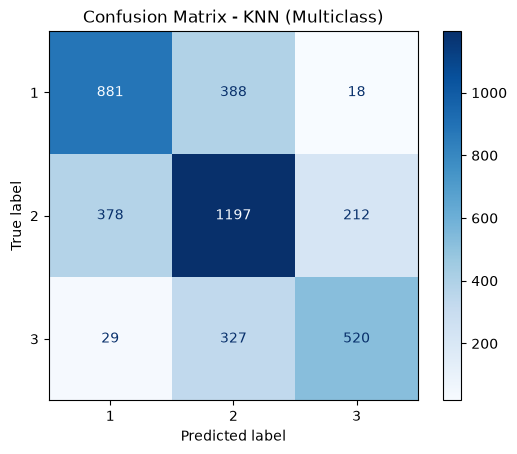

In [68]:
plot_confusion(
    y_test_knn_multi, pred_knn_multi,
    title="Confusion Matrix - KNN (Multiclass)",
    display_labels=best_knn_multi.classes_,
)

### **KNN Classifier - Binary classification**

#### Selecting features

In [69]:
features_knn_bi = [
    'Avg_popularity_log',
    'YearPublished',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'NumAlternates_log',
    'ComAgeRec',
]

X_train_knn_bi = X_train[features_knn_bi]
y_train_knn_bi = y_train['is_long_game']
X_test_knn_bi = X_test[features_knn_bi]
y_test_knn_bi = y_test['is_long_game']

#### Hyperparameter Tuning using Grid Search technique and Cross-Validation

In [70]:
pipe_knn_bi = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn_bi = {
    "knn__n_neighbors": range(1, 31),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"],
}

best_knn_bi, pred_knn_bi = tune_and_evaluate(
    pipe_knn_bi, param_grid_knn_bi,
    X_train_knn_bi, y_train_knn_bi,
    X_test_knn_bi, y_test_knn_bi,
    scoring="f1", label="KNN binary",
)

Starting hyperparameter tuning - KNN binary...
Fitting 5 folds for each of 120 candidates, totalling 600 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 27, 'knn__weights': 'distance'}
Best cross-validation f1 score: 77.78%

Final results on the test set:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      2179
           1       0.81      0.75      0.78      1771

    accuracy                           0.81      3950
   macro avg       0.81      0.80      0.81      3950
weighted avg       0.81      0.81      0.81      3950



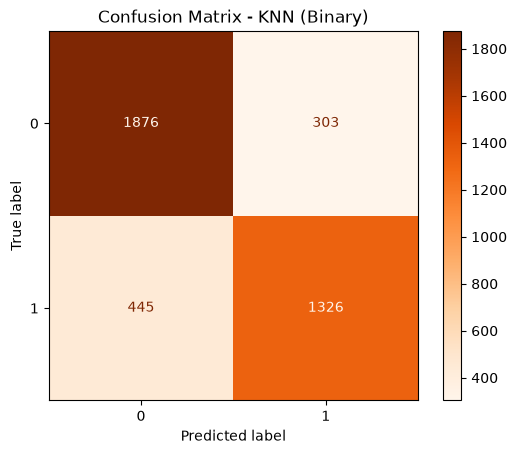

In [71]:
plot_confusion(
    y_test_knn_bi, pred_knn_bi,
    title="Confusion Matrix - KNN (Binary)",
    cmap="Oranges",
)

### **Naive Bayes Classifier**

#### GaussianNB()

Designed to handle **continuous variables** (real-valued features such as temperature, height, or weight). Its functioning is based on the statistical assumption that the data within each class follows a normal (Gaussian) distribution. The model estimates the mean and standard deviation for each feature and uses these parameters to calculate the probability that a given value belongs to a specific class.

When applied to categorical or binary data (where values are only 0 and 1, with no intermediate values), the model makes a conceptual mistake: it attempts to fit a continuous distribution to step-like data, assigning probabilities to nonexistent intermediate values and potentially reducing prediction accuracy.

#### CategoricalNB()

Designed to work with **discrete variables**. It does not assume any Gaussian distribution and instead relies on a frequency-based approach. The algorithm assumes that features follow a categorical (Multinomial) distribution and estimates probabilities by counting how frequently each category appears within each class.

When using continuous variables, they must first be transformed through **discretization** (binning). However, Scikit-learn does not accept string categories directly, so categorical values must be encoded into consecutive integer values using `OrdinalEncoder`.

#### Multiclass classification with **GaussianNB()**

In [72]:
# Select continuous features only
continuous_features_multi_gnb = [
    'Avg_popularity_log',
    'GameWeight',
    'MaxPlayers',
    'MinPlayers',
    'NumAlternates_log',
    'YearPublished',
]

X_train_multi_gnb = X_train[continuous_features_multi_gnb]
y_train_multi_gnb = y_train['Rating']
X_test_multi_gnb = X_test[continuous_features_multi_gnb]
y_test_multi_gnb = y_test['Rating']

gnb_model_multi = GaussianNB()
gnb_model_multi.fit(X_train_multi_gnb, y_train_multi_gnb)
y_pred_multi_gnb = gnb_model_multi.predict(X_test_multi_gnb)

#### Results

In [73]:
print("\nGaussianNB Classification Report - Test Set:")
print(classification_report(y_test_multi_gnb, y_pred_multi_gnb))


GaussianNB Classification Report - Test Set:
              precision    recall  f1-score   support

           1       0.63      0.66      0.64      1287
           2       0.59      0.61      0.60      1787
           3       0.66      0.59      0.62       876

    accuracy                           0.62      3950
   macro avg       0.63      0.62      0.62      3950
weighted avg       0.62      0.62      0.62      3950



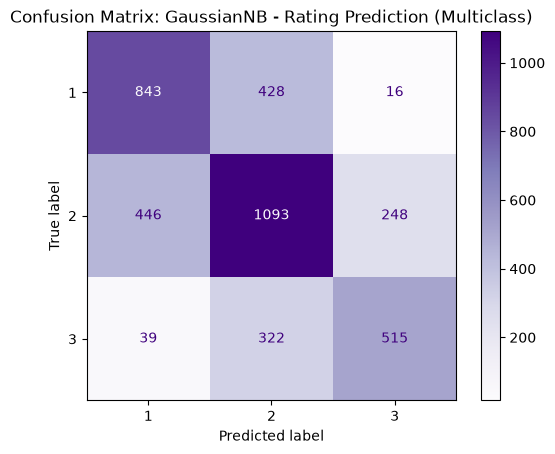

In [74]:
plot_confusion(
    y_test_multi_gnb, y_pred_multi_gnb,
    title="Confusion Matrix: GaussianNB - Rating Prediction (Multiclass)",
    cmap="Purples",
)

#### Multiclass classification with **CategoricalNB()**

In [75]:
# Continuous features: these will be discretized into bins
continuous_features_multi_cnb = [
    'GameWeight',
    'MaxPlayers',
    'YearPublished',
    'NumAlternates_log',
    'Avg_popularity_log',
]

cat_features_multi_cnb = [
    'MinPlayers',
    'Kickstarted',
]

all_features_multi_cnb = continuous_features_multi_cnb + cat_features_multi_cnb

X_train_multi_cnb = X_train[all_features_multi_cnb]
X_test_multi_cnb = X_test[all_features_multi_cnb]
y_train_multi_cnb = y_train['Rating']
y_test_multi_cnb = y_test['Rating']

In [76]:
# Setup the preprocessor:
# - KBinsDiscretizer converts continuous values into discrete quantile bins
# - OrdinalEncoder converts categories into integers
#   (unknown_value=10 keeps encoded values >= n_bins, so CategoricalNB never
#   confuses an "unseen category" code with a real bin index)
preprocessor_multi_cnb = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile'), continuous_features_multi_cnb),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=10), cat_features_multi_cnb),
    ]
)

# Wrap preprocessing and classifier in a single Pipeline so that both
# training and test data go through identical transformations
cat_nb_model_multi = Pipeline(steps=[
    ('preprocessor', preprocessor_multi_cnb),
    ('classifier', CategoricalNB()),
])

cat_nb_model_multi.fit(X_train_multi_cnb, y_train_multi_cnb)
y_pred_multi_cnb = cat_nb_model_multi.predict(X_test_multi_cnb)

/home/tommaso/projects/Board-Game-Data-Analytics/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/tommaso/projects/Board-Game-Data-Analytics/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/tommaso/projects/Board-Game-Data-Analytics/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(


#### Results

In [77]:
print("--- Categorical Naive Bayes: Rating Classification ---")
print("\nClassification Report:")
print(classification_report(y_test_multi_cnb, y_pred_multi_cnb))

--- Categorical Naive Bayes: Rating Classification ---

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.66      0.67      1287
           2       0.61      0.67      0.64      1787
           3       0.69      0.58      0.63       876

    accuracy                           0.65      3950
   macro avg       0.66      0.64      0.65      3950
weighted avg       0.65      0.65      0.65      3950



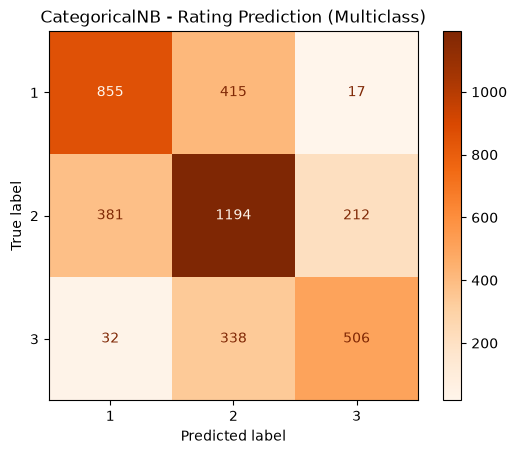

In [78]:
plot_confusion(
    y_test_multi_cnb, y_pred_multi_cnb,
    title="CategoricalNB - Rating Prediction (Multiclass)",
    display_labels=[1, 2, 3],  # Corresponding to Low, Medium, High
    cmap="Oranges",
)

#### Binary classification with **GaussianNB()**

In [79]:
# Select continuous features only
continuous_features_bi_gnb = [
    'Avg_popularity_log',
    'ComAgeRec',
    'GameWeight',
    'MaxPlayers',
    'NumExpansions_log',
    'YearPublished',
    'MinPlayers',
]

X_train_bi_gnb = X_train[continuous_features_bi_gnb]
X_test_bi_gnb = X_test[continuous_features_bi_gnb]
y_train_bi_gnb = y_train['is_long_game']
y_test_bi_gnb = y_test['is_long_game']

gnb_model_bi = GaussianNB()
gnb_model_bi.fit(X_train_bi_gnb, y_train_bi_gnb)
y_pred_bi_gnb = gnb_model_bi.predict(X_test_bi_gnb)

#### Results

In [80]:
print("--- Gaussian Naive Bayes: Binary Classification (is_long_game) ---")
print("\nClassification Report:")
print(classification_report(y_test_bi_gnb, y_pred_bi_gnb))

--- Gaussian Naive Bayes: Binary Classification (is_long_game) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      2179
           1       0.79      0.71      0.74      1771

    accuracy                           0.78      3950
   macro avg       0.78      0.78      0.78      3950
weighted avg       0.78      0.78      0.78      3950



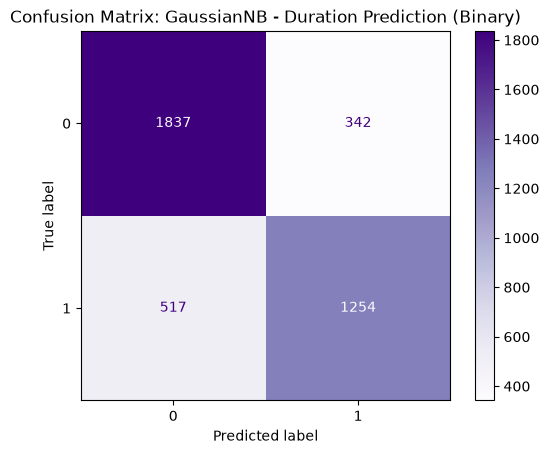

In [81]:
plot_confusion(
    y_test_bi_gnb, y_pred_bi_gnb,
    title="Confusion Matrix: GaussianNB - Duration Prediction (Binary)",
    cmap="Purples",
)

#### Binary classification with **CategoricalNB()**

In [82]:
# Continuous features: these will be discretized into bins
continuous_features_bi_cnb = [
    'ComAgeRec',
    'GameWeight',
    'MaxPlayers',
    'YearPublished',
    'NumWeightVotes_log',
    'Avg_popularity_log',
]

cat_features_bi_cnb = [
    'MinPlayers',
    'Kickstarted',
]

all_features_bi_cnb = continuous_features_bi_cnb + cat_features_bi_cnb

X_train_bi_cnb = X_train[all_features_bi_cnb]
X_test_bi_cnb = X_test[all_features_bi_cnb]
y_train_bi_cnb = y_train['is_long_game']
y_test_bi_cnb = y_test['is_long_game']

In [83]:
# Setup the preprocessor: KBinsDiscretizer converts continuous data into 5
# ordinal bins, OrdinalEncoder converts categories to integers
# (unknown_value=10 keeps encoded values outside the real bin range)
preprocessor_bi_cnb = ColumnTransformer(
    transformers=[
        ('num', KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile'), continuous_features_bi_cnb),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=10), cat_features_bi_cnb),
    ]
)

cat_nb_model_bi = Pipeline(steps=[
    ('preprocessor', preprocessor_bi_cnb),
    ('classifier', CategoricalNB()),
])

cat_nb_model_bi.fit(X_train_bi_cnb, y_train_bi_cnb)
y_pred_bi_cnb = cat_nb_model_bi.predict(X_test_bi_cnb)

/home/tommaso/projects/Board-Game-Data-Analytics/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


#### Results

In [84]:
print("--- Categorical Naive Bayes: Binary Classification (is_long_game) ---")
print("\nClassification Report:")
print(classification_report(y_test_bi_cnb, y_pred_bi_cnb))

--- Categorical Naive Bayes: Binary Classification (is_long_game) ---

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      2179
           1       0.76      0.75      0.76      1771

    accuracy                           0.78      3950
   macro avg       0.78      0.78      0.78      3950
weighted avg       0.78      0.78      0.78      3950



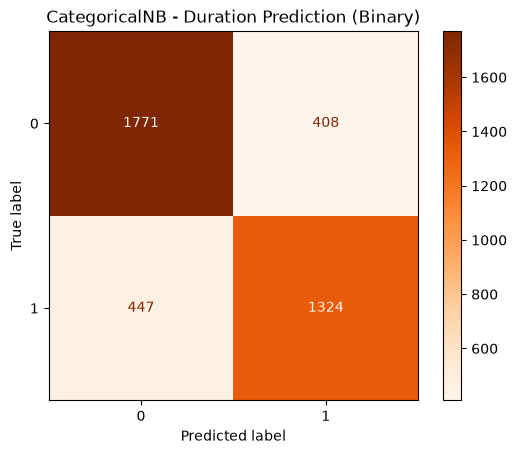

In [85]:
plot_confusion(
    y_test_bi_cnb, y_pred_bi_cnb,
    title="CategoricalNB - Duration Prediction (Binary)",
    display_labels=["0", "1"],
    cmap="Oranges",
)

### **Decision Tree Classifier**

#### Selecting features

In [86]:
features_multi_dt = [
    'Avg_popularity_log',
    'YearPublished',
    'GameWeight',
    'MaxPlayers',
    'NumWeightVotes_log',
]

# Kickstarted, MinPlayers and NumAlternates_log were initially included
# but later removed because they were not relevant (see feature importance below)

X_train_multi_dt = X_train[features_multi_dt]
y_train_multi_dt = y_train['Rating']
X_test_multi_dt = X_test[features_multi_dt]
y_test_multi_dt = y_test['Rating']

#### Model initialization

In [87]:
%%time
# max_depth=5 is a good starting point to avoid overfitting
dt_baseline_multi = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42, class_weight='balanced')

CPU times: user 8 μs, sys: 2 μs, total: 10 μs
Wall time: 11.2 μs


#### Training

In [88]:
dt_baseline_multi.fit(X_train_multi_dt, y_train_multi_dt)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

#### Prediction

In [89]:
y_pred_multi_dt = dt_baseline_multi.predict(X_test_multi_dt)

#### Evaluation

In [90]:
print("\nReport:")
print(classification_report(y_test_multi_dt, y_pred_multi_dt))


Report:
              precision    recall  f1-score   support

           1       0.57      0.85      0.68      1287
           2       0.66      0.37      0.48      1787
           3       0.61      0.72      0.66       876

    accuracy                           0.61      3950
   macro avg       0.61      0.65      0.61      3950
weighted avg       0.62      0.61      0.59      3950



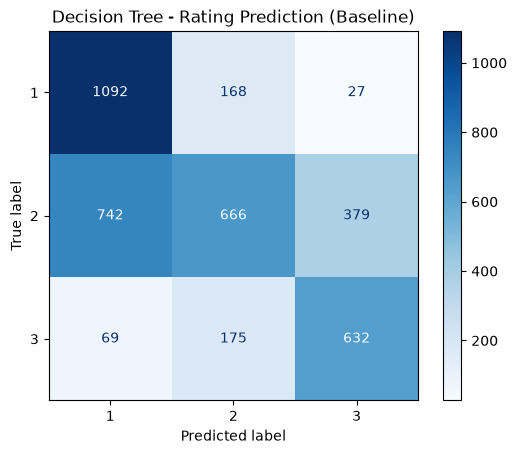

In [91]:
plot_confusion(
    y_test_multi_dt, y_pred_multi_dt,
    title="Decision Tree - Rating Prediction (Baseline)",
    display_labels=["1", "2", "3"],
)

In [92]:
print_feature_importance(features_multi_dt, dt_baseline_multi.feature_importances_)

Feature importance
GameWeight: 0.4369
YearPublished: 0.3993
Avg_popularity_log: 0.1524
NumWeightVotes_log: 0.0094
MaxPlayers: 0.0021


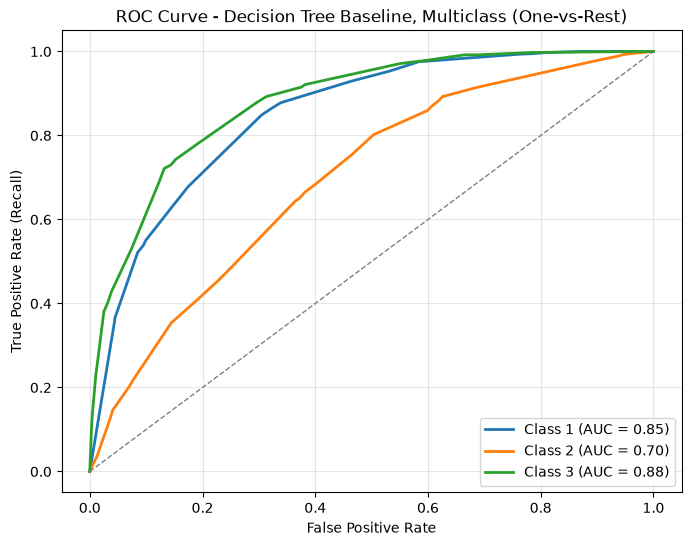

In [93]:
plot_multiclass_roc(
    dt_baseline_multi, X_test_multi_dt, y_test_multi_dt,
    classes=[1, 2, 3],
    title="ROC Curve - Decision Tree Baseline, Multiclass (One-vs-Rest)",
)

#### Optimization

In [94]:
param_grid_dt_multi = {
    'criterion': ['gini', 'entropy'],        # Impurity measure
    'max_depth': [5, 8, 10, 12, 15, None],   # Controls tree complexity
    'min_samples_leaf': [10, 20, 30, 40, 60] # Smoothing (higher = less overfitting)
}

best_dt_multi, y_pred_multi_dt_best = tune_and_evaluate(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt_multi,
    X_train_multi_dt, y_train_multi_dt,
    X_test_multi_dt, y_test_multi_dt,
    scoring='f1_weighted', label="Decision Tree multiclass",
)

Starting hyperparameter tuning - Decision Tree multiclass...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 40}
Best cross-validation f1_weighted score: 62.45%

Final results on the test set:
              precision    recall  f1-score   support

           1       0.64      0.76      0.69      1287
           2       0.67      0.46      0.54      1787
           3       0.58      0.80      0.67       876

    accuracy                           0.63      3950
   macro avg       0.63      0.67      0.64      3950
weighted avg       0.64      0.63      0.62      3950



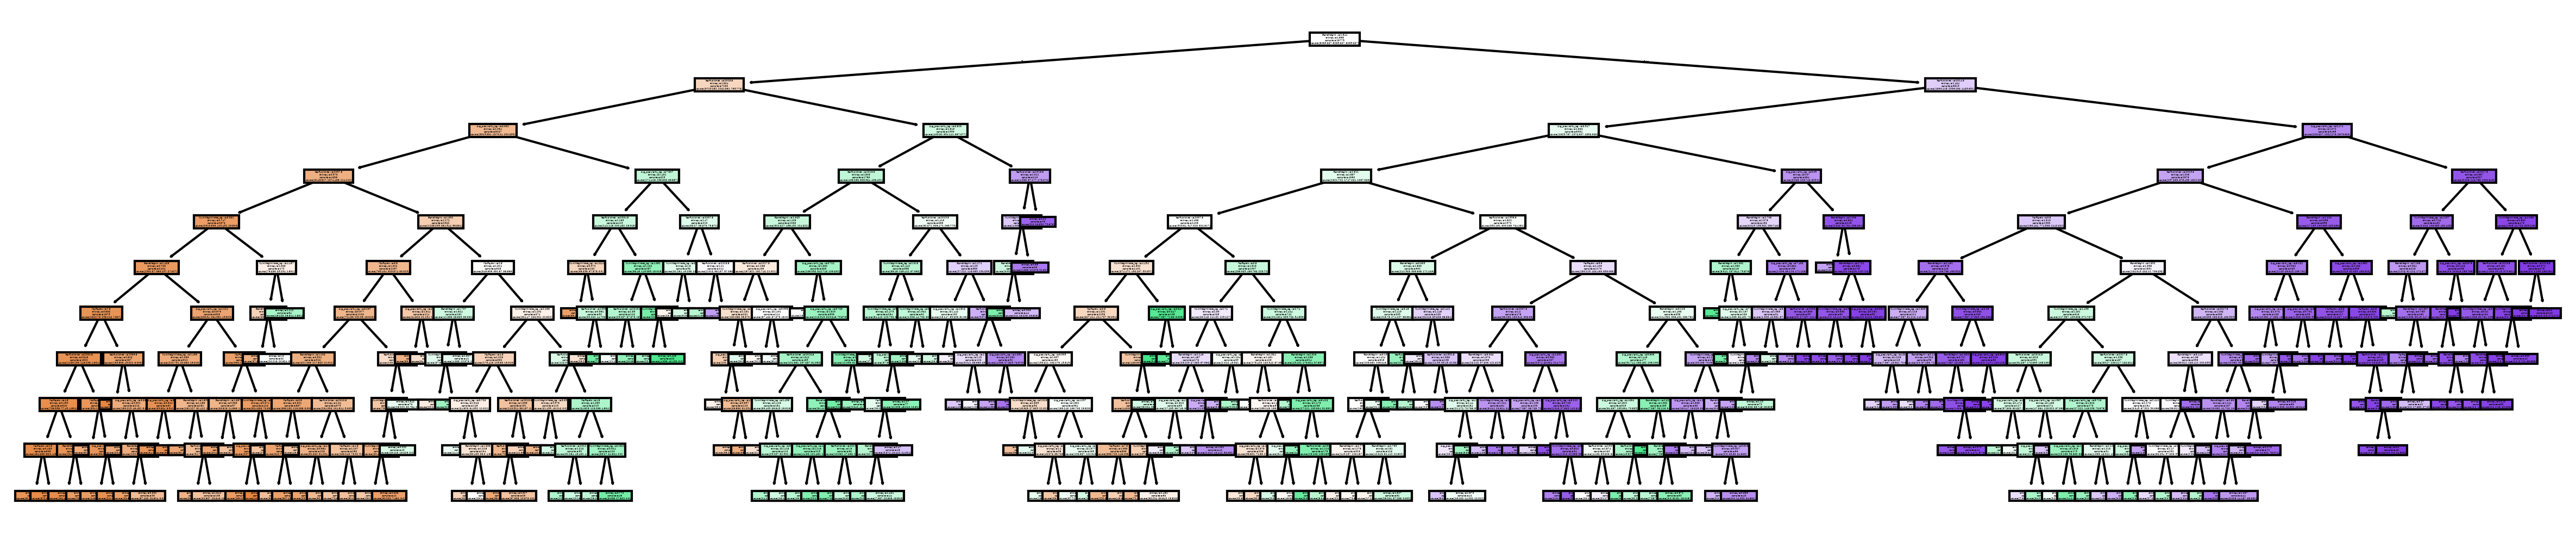

In [95]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(best_dt_multi, feature_names=features_multi_dt, filled=True)
plt.show()

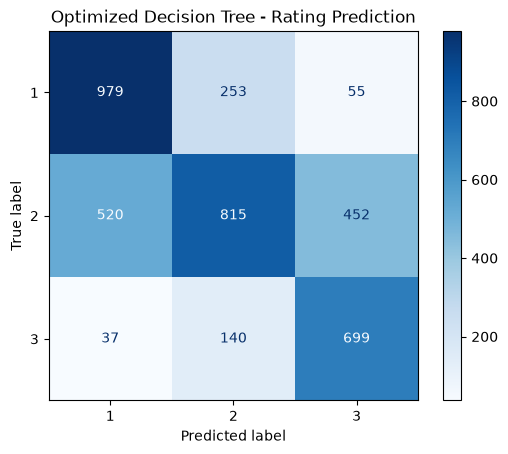

In [96]:
plot_confusion(
    y_test_multi_dt, y_pred_multi_dt_best,
    title="Optimized Decision Tree - Rating Prediction",
    display_labels=["1", "2", "3"],
)

In [97]:
print_feature_importance(features_multi_dt, best_dt_multi.feature_importances_)

Feature importance
GameWeight: 0.3708
YearPublished: 0.3486
Avg_popularity_log: 0.1717
NumWeightVotes_log: 0.0632
MaxPlayers: 0.0457


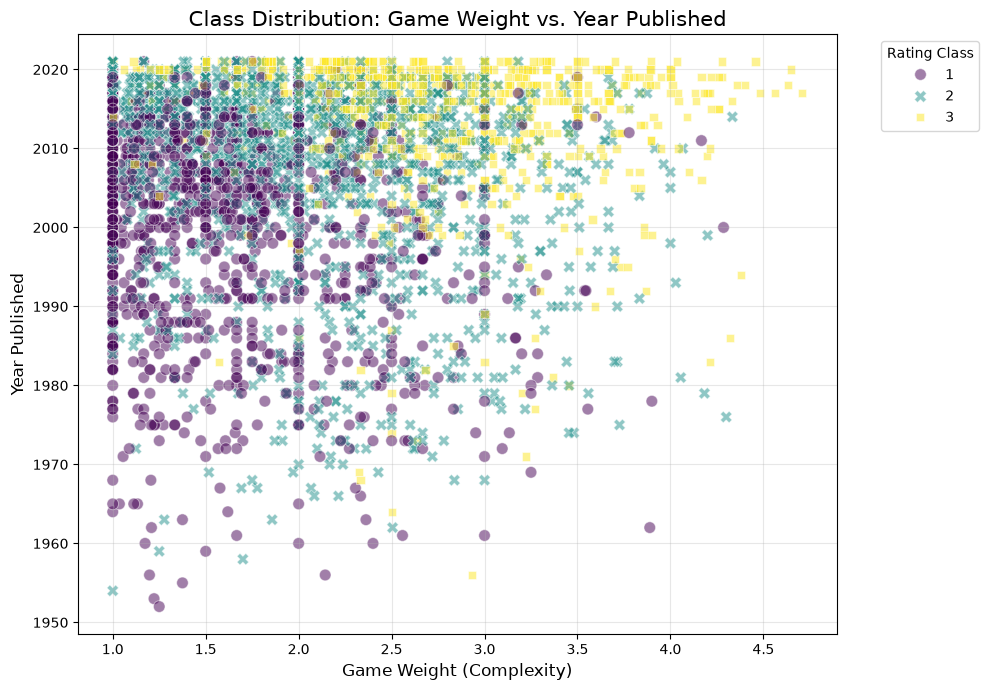

In [98]:
# Create a temporary DataFrame with the filtered data (use .copy() to avoid
# modifying the original test set)
df_plot_multi = X_test_multi_dt.copy()
df_plot_multi['Class'] = y_test_multi_dt.values  # Add the Rating target as 'Class'

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot_multi,
    x='GameWeight',      # X-axis: Complexity (usually the most important feature)
    y='YearPublished',   # Y-axis: Year of publication
    hue='Class',         # Color points based on the target class (1, 2, 3)
    palette='viridis',   # Use a distinguishable color palette
    style='Class',       # Change point shape for accessibility and clarity
    alpha=0.5,           # Set transparency to handle overplotting
    s=70                 # Set point size
)

plt.title('Class Distribution: Game Weight vs. Year Published', fontsize=15)
plt.xlabel('Game Weight (Complexity)', fontsize=12)
plt.ylabel('Year Published', fontsize=12)

# Move the legend outside the plot to prevent overlap
plt.legend(title='Rating Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()  # Adjust layout to prevent label clipping
plt.show()

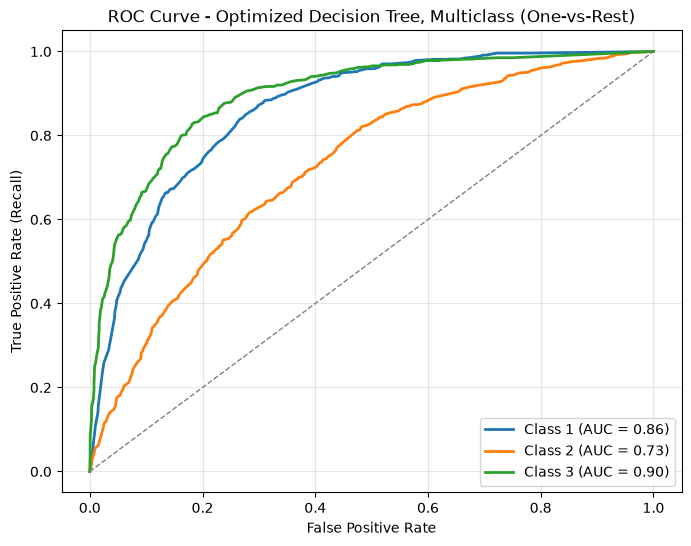

In [99]:
plot_multiclass_roc(
    best_dt_multi, X_test_multi_dt, y_test_multi_dt,
    classes=[1, 2, 3],
    title="ROC Curve - Optimized Decision Tree, Multiclass (One-vs-Rest)",
)

### Binary Decision Tree

#### Selecting features

In [100]:
features_bi_dt = [
    'ComAgeRec',
    'Kickstarted',
    'GameWeight',
    'MinPlayers',
    'MaxPlayers',
    'YearPublished',
    'Avg_popularity_log',
    'NumAlternates_log',
]

X_train_bi_dt = X_train[features_bi_dt]
y_train_bi_dt = y_train['is_long_game']
X_test_bi_dt = X_test[features_bi_dt]
y_test_bi_dt = y_test['is_long_game']

#### Model initialization, training and evaluation

In [101]:
%%time
# max_depth=5 is a good starting point to avoid overfitting
dt_baseline_bi = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42, class_weight='balanced')

CPU times: user 6 μs, sys: 1 μs, total: 7 μs
Wall time: 9.54 μs


In [102]:
dt_baseline_bi.fit(X_train_bi_dt, y_train_bi_dt)
y_pred_bi_dt = dt_baseline_bi.predict(X_test_bi_dt)

print("\nReport:")
print(classification_report(y_test_bi_dt, y_pred_bi_dt))


Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      2179
           1       0.79      0.77      0.78      1771

    accuracy                           0.81      3950
   macro avg       0.80      0.80      0.80      3950
weighted avg       0.81      0.81      0.81      3950



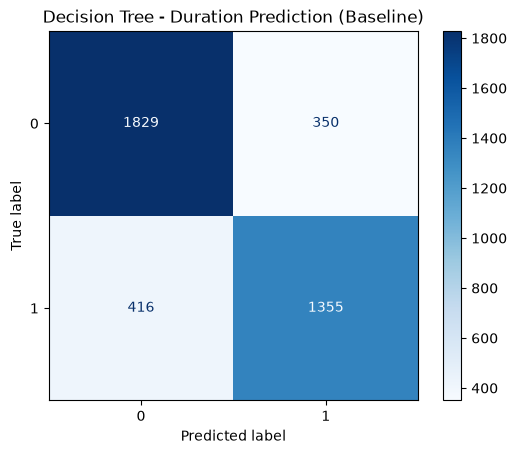

In [103]:
plot_confusion(
    y_test_bi_dt, y_pred_bi_dt,
    title="Decision Tree - Duration Prediction (Baseline)",
    display_labels=["0", "1"],
)

In [104]:
print_feature_importance(features_bi_dt, dt_baseline_bi.feature_importances_)

Feature importance
GameWeight: 0.8268
ComAgeRec: 0.0824
MaxPlayers: 0.0404
YearPublished: 0.0330
Avg_popularity_log: 0.0109
NumAlternates_log: 0.0058
MinPlayers: 0.0007
Kickstarted: 0.0000


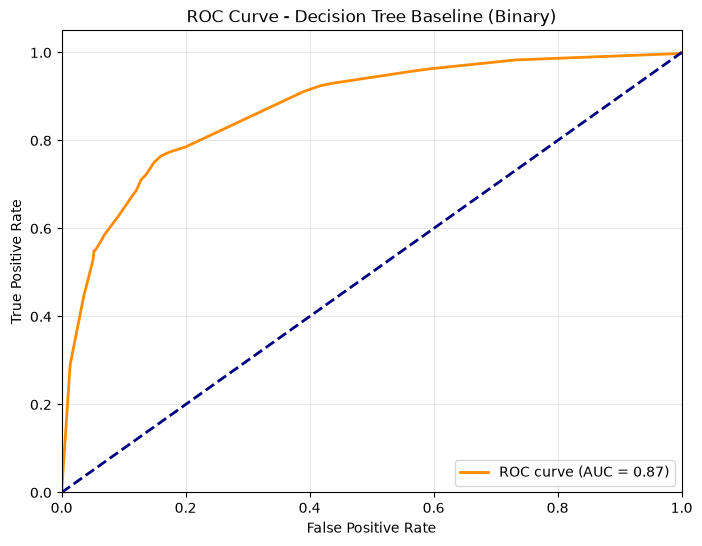

In [105]:
plot_binary_roc(
    dt_baseline_bi, X_test_bi_dt, y_test_bi_dt,
    title="ROC Curve - Decision Tree Baseline (Binary)",
)

#### Optimization

In [106]:
param_grid_dt_bi = {
    'criterion': ['gini', 'entropy'],         # Measures of impurity
    'max_depth': [5, 8, 10, 12, 15, None],    # Control tree complexity
    'min_samples_leaf': [10, 20, 30, 40, 60], # Control smoothing (higher = smoother)
}

best_dt_bi, y_pred_bi_dt_best = tune_and_evaluate(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt_bi,
    X_train_bi_dt, y_train_bi_dt,
    X_test_bi_dt, y_test_bi_dt,
    scoring='f1_weighted', label="Decision Tree binary",
)

Starting hyperparameter tuning - Decision Tree binary...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

BEST CONFIGURATION FOUND:
-------------------------------
Best params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20}
Best cross-validation f1_weighted score: 80.35%

Final results on the test set:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      2179
           1       0.78      0.78      0.78      1771

    accuracy                           0.80      3950
   macro avg       0.80      0.80      0.80      3950
weighted avg       0.80      0.80      0.80      3950



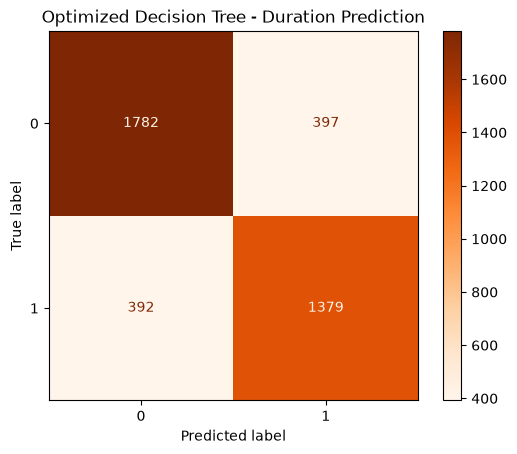

In [107]:
plot_confusion(
    y_test_bi_dt, y_pred_bi_dt_best,
    title="Optimized Decision Tree - Duration Prediction",
    display_labels=["0", "1"],
    cmap="Oranges",
)

In [108]:
print_feature_importance(features_bi_dt, best_dt_bi.feature_importances_)

Feature importance
GameWeight: 0.7620
ComAgeRec: 0.0848
MaxPlayers: 0.0571
YearPublished: 0.0530
Avg_popularity_log: 0.0225
MinPlayers: 0.0091
NumAlternates_log: 0.0085
Kickstarted: 0.0030


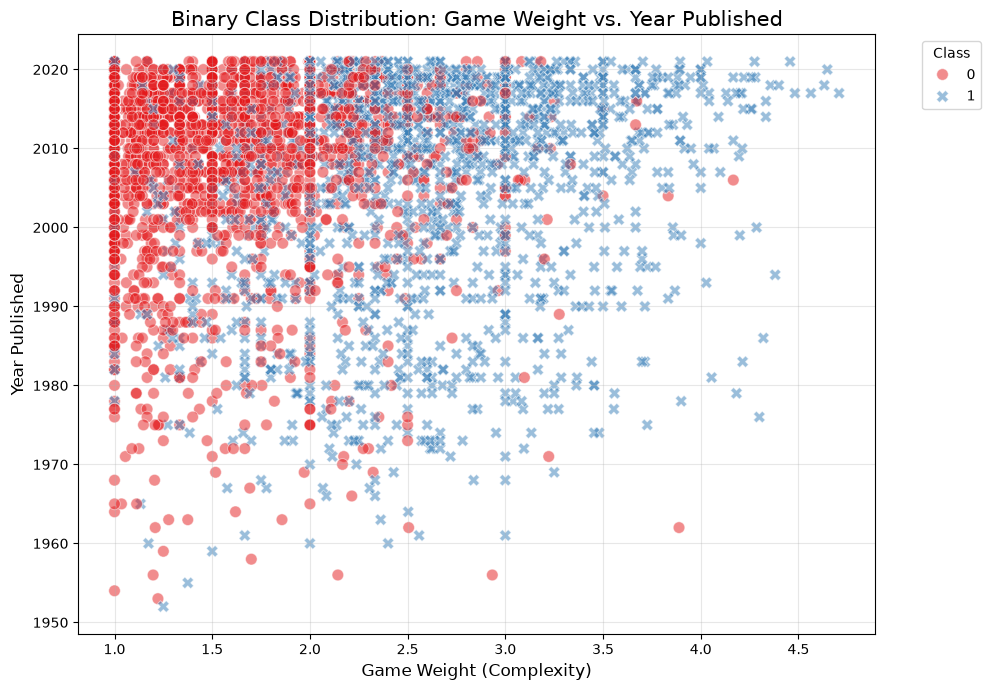

In [109]:
# Create a temporary DataFrame with the filtered data (use .copy() to avoid
# modifying the original test set)
df_plot_bi = X_test_bi_dt.copy()
df_plot_bi['Class'] = y_test_bi_dt.values  # Add the binary target as 'Class'

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_plot_bi,
    x='GameWeight',      # X-axis: Complexity
    y='YearPublished',   # Y-axis: Year of publication
    hue='Class',         # Color points based on the binary class (0, 1)
    style='Class',       # Different markers for the two classes
    palette='Set1',      # High-contrast palette suitable for binary classes
    alpha=0.5,           # Transparency to handle overplotting
    s=70                 # Point size
)

plt.title('Binary Class Distribution: Game Weight vs. Year Published', fontsize=15)
plt.xlabel('Game Weight (Complexity)', fontsize=12)
plt.ylabel('Year Published', fontsize=12)

plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

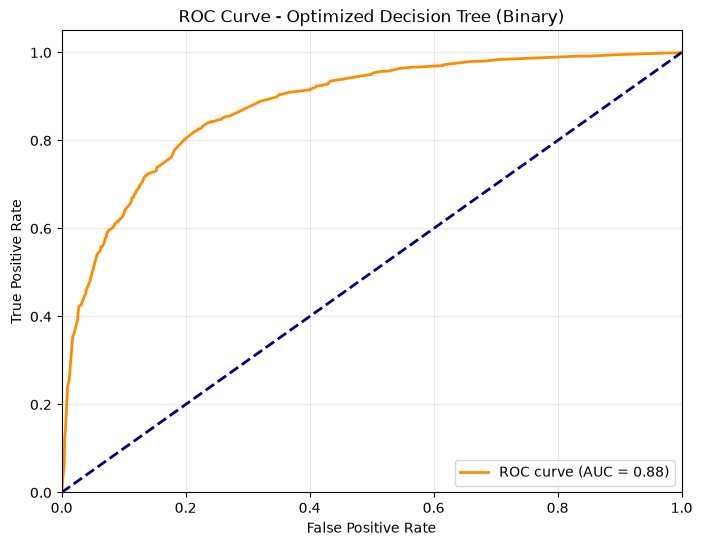

In [110]:
plot_binary_roc(
    best_dt_bi, X_test_bi_dt, y_test_bi_dt,
    title="ROC Curve - Optimized Decision Tree (Binary)",
)

### Learning Curves

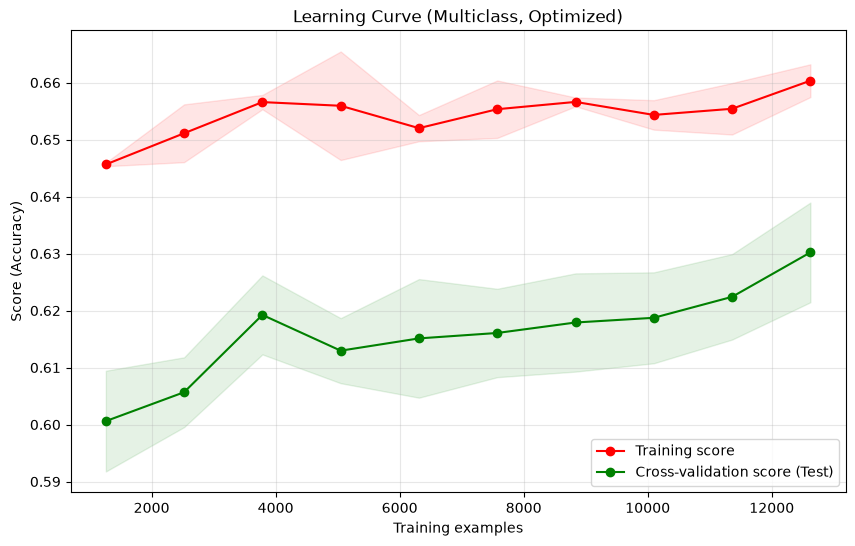

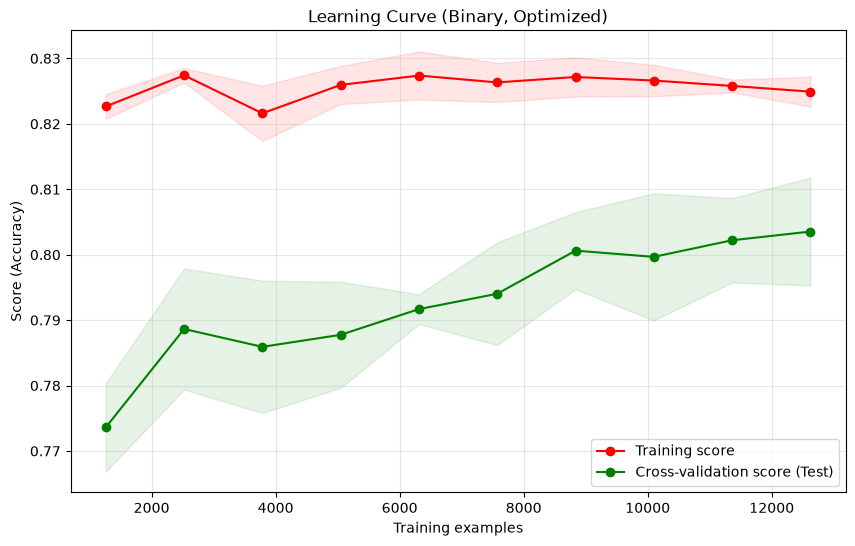

In [111]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5, n_jobs=-1):
    """
    Plot a Learning Curve to diagnose over/underfitting: training score vs.
    cross-validation score as a function of the number of training examples.
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score (Accuracy)")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10),  # 10 progressive points
        scoring='accuracy',
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid(True, alpha=0.3)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                      train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                      test_scores_mean + test_scores_std, alpha=0.1, color="g")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score (Test)")

    plt.legend(loc="best")
    return plt


plot_learning_curve(
    best_dt_multi,
    "Learning Curve (Multiclass, Optimized)",
    X_train_multi_dt,
    y_train_multi_dt,
    cv=5,
)
plt.show()

plot_learning_curve(
    best_dt_bi,
    "Learning Curve (Binary, Optimized)",
    X_train_bi_dt,
    y_train_bi_dt,
    cv=5,
)
plt.show()

> **Note - Feature Elimination via Backward Selection**
>
> Following the initial training, we analyzed the feature importance metrics and identified a clear distinction between dominant predictors (e.g., `GameWeight`, `ComAgeRec`) and marginal features (`MinPlayers`, `NumAlternates_log`, `NumWeightVotes_log`, all < 2% importance).
>
> We conducted an A/B test to validate the removal of these marginal features:
> - **Model A** (full feature set): accuracy 80.46%
> - **Model B** (top-5 features only): accuracy 80.59%
>
> Model B matched, and marginally exceeded, the performance of the full model (+0.13%). Given how small this gap is relative to typical cross-validation fold variance, it should be read as evidence that the removed variables were **not harmful** rather than as proof they meaningfully improved the model. This supported streamlining the feature set (`GameWeight`, `ComAgeRec`, `YearPublished`, `MaxPlayers`, `Avg_popularity_log`) in the interest of parsimony, while keeping accuracy above the 80% project target.

# Project Report: Classification Analysis of Board Games using Decision Trees

This project utilizes Decision Tree Classifiers to analyze the BoardGame dataset, focusing on two distinct prediction tasks to understand the drivers of game success and mechanics. The primary objective is the multiclass classification of board game ratings into three quality tiers, specifically low, medium, and high. A secondary task involves the binary classification of game duration to distinguish between long and short games using a created variable named is_long_game.

For the task of rating classification, the data was first prepared by removing identifier variables such as Name and BGGId to prevent data leakage and ensure the model learned from relevant game characteristics. The initial model was trained on a comprehensive set of attributes including physical properties like GameWeight and player counts, as well as community metrics and metadata such as YearPublished and Kickstarted status. Upon training, a feature importance analysis revealed a highly skewed distribution of predictive power. GameWeight emerged as the overwhelmingly dominant factor, accounting for approximately 72% of the model's decision-making process, which indicates that game complexity is the strongest single indicator of a game's rating tier. The Community Age Recommendation also played a significant role, contributing roughly 10% to the prediction, while the YearPublished provided a moderate signal.

Conversely, the analysis demonstrated that the funding source had no impact on the model's ability to predict quality. The Kickstarted variable recorded a Gini importance of zero, meaning it was never utilized by the tree for splitting data. Similarly, other variables such as MinPlayers and logarithmic alternate metrics contributed negligible information to the classifier. Guided by these insights, a backward elimination strategy was employed to refine the model by removing these non-predictive features. A comparative test confirmed that a streamlined model using only the top five features slightly outperformed the model using the full feature set, improving accuracy from 80.46% to 80.59%. This validated the decision to remove noise variables and adhere to the principle of parsimony.

In parallel to the rating analysis, a second Decision Tree was applied to the binary target is_long_game. This task aimed to classify games based on their duration, shifting the focus from quality assessment to mechanical categorization. This secondary analysis further demonstrated the versatility of the Decision Tree algorithm in handling different types of classification targets within the same domain.

In conclusion, the study demonstrates that predicting board game rating tiers with high accuracy is achievable using a single Decision Tree. The optimized model, configured with a maximum depth of eight and using the Gini impurity criterion, confirms that game complexity and target audience age are the definitive factors for predicting success on BoardGameGeek. The analysis conclusively shows that specific metadata such as Kickstarter funding status and minimum player counts are statistically irrelevant for determining the quality tier of a board game in this context.

### **Model comparison**

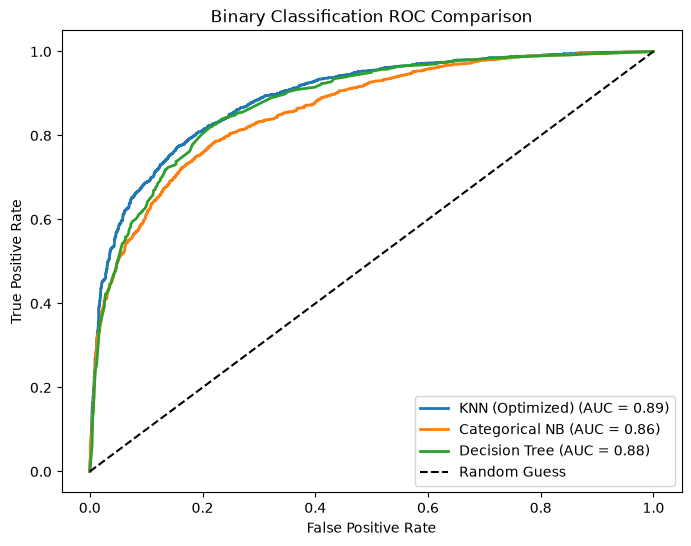

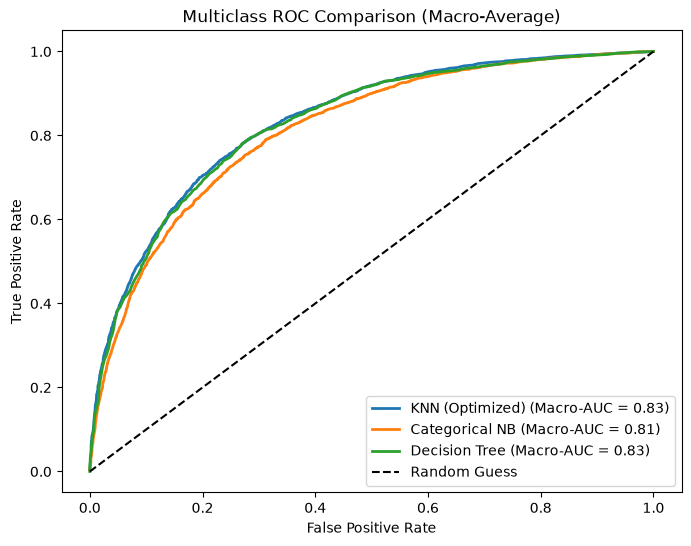

In [112]:
# BINARY CLASSIFICATION
binary_models_map = {
    "KNN (Optimized)": {
        "model": best_knn_bi,
        "X": X_test_knn_bi,
        "y": y_test_knn_bi,
    },
    "Categorical NB": {
        "model": cat_nb_model_bi,
        "X": X_test_bi_cnb,
        "y": y_test_bi_cnb,
    },
    "Decision Tree": {
        "model": best_dt_bi,
        "X": X_test_bi_dt,
        "y": y_test_bi_dt,
    },
}

plt.figure(figsize=(8, 6))

for name, data in binary_models_map.items():
    try:
        y_prob = data['model'].predict_proba(data['X'])[:, 1]
        fpr, tpr, _ = roc_curve(data['y'], y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    except Exception as e:
        print(f"Could not plot {name}: {e}. (Check that this model's cell has been run)")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Classification ROC Comparison')
plt.legend(loc="lower right")
plt.show()

# MULTICLASS CLASSIFICATION
multi_models_map = {
    "KNN (Optimized)": {
        "model": best_knn_multi,
        "X": X_test_knn_multi,
        "y": y_test_knn_multi,
    },
    "Categorical NB": {
        "model": cat_nb_model_multi,
        "X": X_test_multi_cnb,
        "y": y_test_multi_cnb,
    },
    "Decision Tree": {
        "model": best_dt_multi,
        "X": X_test_multi_dt,
        "y": y_test_multi_dt,
    },
}

plt.figure(figsize=(8, 6))
classes = [1, 2, 3]

for name, data in multi_models_map.items():
    try:
        y_test_bin = label_binarize(data['y'], classes=classes)
        n_classes = y_test_bin.shape[1]

        y_score = data['model'].predict_proba(data['X'])

        # Macro-average ROC
        fpr = dict()
        tpr = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes

        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=2, label=f'{name} (Macro-AUC = {macro_auc:.2f})')

    except Exception as e:
        print(f"Could not plot {name} (multiclass): {e}")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Comparison (Macro-Average)')
plt.legend(loc="lower right")
plt.show()